In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [6]:
final_clean_strained = split_by_mouse(final_clean_strained)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained, num_features, cat_features, log_features, minmax_features
)

In [7]:
final_clean_strained.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [8]:
cols = [
    "Amplitude",
    "Slope",
    "Distance",
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

reformatted = []

for col in cols:
    df = (
        final_clean_strained.pivot_table(
            index=["Subject", "Noise", "Time_hrs", "Frequency"],
            columns="Level",
            values=col,
        )
        .rename_axis(columns="Level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted.append(df)
reformatted = pd.concat(reformatted, axis=1)

# Add Synapses column (constant per Subject/Freq)
synapses = final_clean_strained.groupby(["Subject", "Noise", "Time_hrs", "Frequency"])[
    "SynapsesPerIHC"
].mean()
groups = final_clean_strained.groupby(["Subject", "Noise", "Time_hrs", "Frequency"])[
    ["DataGroup", "Strain_b"]
].first()

# Combine
reformatted = reformatted.join(synapses).join(groups)

# fill NaNs with interpolated/extrapolated values:
for col in cols:
    amp_cols = [c for c in reformatted.columns if c.startswith(col)]
    reformatted[amp_cols] = reformatted[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )
reformatted.reset_index(inplace=True)
reformatted.head(10)

,Subject,Noise,Time_hrs,Frequency,Amplitude_10.0,Amplitude_15.0,Amplitude_20.0,Amplitude_25.0,Amplitude_30.0,Amplitude_35.0,...,TroughIRightCurvature_50.0,TroughIRightCurvature_55.0,TroughIRightCurvature_60.0,TroughIRightCurvature_65.0,TroughIRightCurvature_70.0,TroughIRightCurvature_75.0,TroughIRightCurvature_80.0,SynapsesPerIHC,DataGroup,Strain_b
0,WPZ100,0.00,56.0,8.0,0.077961,0.077961,0.029777,0.090885,0.137358,0.296385,...,4.514280,14.796865,25.079451,13.892941,2.706432,1.739748,0.773064,15.892142,Test,1
1,WPZ100,0.00,56.0,11.3,0.050718,0.050718,0.000000,0.168245,0.302752,0.392846,...,7.466661,6.280679,5.094698,2.653182,0.211666,0.260892,0.310118,16.492360,Test,1
2,WPZ100,0.00,56.0,16.0,0.059556,0.077295,0.047106,0.121329,0.202553,0.426837,...,5.866059,3.128261,0.390464,0.450276,0.510088,0.333558,0.157028,17.564103,Test,1
3,WPZ100,0.00,56.0,22.6,0.063072,0.063072,0.060886,0.098964,0.223176,0.255710,...,5.496520,3.570113,1.643706,0.862335,0.080963,0.440617,0.800270,17.381424,Test,1
4,WPZ100,0.00,56.0,32.0,0.091900,0.091900,0.257800,0.321347,0.333101,0.498574,...,1.020433,0.821376,0.622318,2.515715,4.409113,2.254731,0.100350,18.314239,Test,1
5,WPZ100,0.00,56.0,45.2,0.079988,0.079988,0.064308,0.129407,0.054423,0.130737,...,0.608373,6.313868,12.019363,6.413762,0.808162,0.566801,0.325440,17.846405,Test,1
6,WPZ101,0.00,56.0,32.0,0.054107,0.087369,0.057180,0.286407,0.411283,0.572701,...,0.556963,11.750996,22.945029,13.590213,4.235397,42.735342,81.235287,16.193497,Train,1
7,WPZ101,0.00,56.0,45.2,0.043558,0.111223,0.131910,0.057465,0.140146,0.098869,...,8.195234,18.925156,4.778665,10.090546,6.866563,17.967283,8.283850,15.351421,Train,1
8,WPZ102,0.94,14.0,8.0,0.067254,0.180315,0.126208,0.006525,0.139418,0.266449,...,4.888168,4.034692,3.181216,14.842119,26.503023,13.575201,0.647380,14.334043,Train,1
9,WPZ102,0.94,14.0,11.3,0.195773,0.029398,0.095163,0.233439,0.310324,0.502138,...,4.024901,3.145657,2.266414,1.203518,0.140623,0.097414,0.054206,16.569307,Train,1


# Elastic Net

In [9]:
num_features = []
cat_features = ["Strain_b"]
log_features = ["Frequency"]
minmax_features = ["Noise", "Time_hrs"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features + minmax_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
        ("minmax_scale", MinMaxScaler(), minmax_features),
    ]
)

In [10]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Lasso training set score: {pipeline.score(X_train, y_train)}")
print(f"Lasso test set score: {pipeline.score(X_test, y_test)}")

Lasso training set score: 0.3414444899684512
Lasso test set score: 0.3973658910828217


In [11]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

41 features were selected
Dropped features: ['Amplitude_10.0' 'Amplitude_15.0' 'Amplitude_25.0' 'Amplitude_30.0'
 'Amplitude_35.0' 'Amplitude_40.0' 'Amplitude_45.0' 'Amplitude_50.0'
 'Amplitude_55.0' 'Amplitude_60.0' 'Amplitude_65.0' 'Amplitude_70.0'
 'Amplitude_75.0' 'Amplitude_80.0' 'Slope_10.0' 'Slope_15.0' 'Slope_25.0'
 'Slope_30.0' 'Slope_35.0' 'Slope_40.0' 'Slope_45.0' 'Slope_50.0'
 'Slope_55.0' 'Slope_60.0' 'Slope_65.0' 'Slope_70.0' 'Slope_75.0'
 'Distance_10.0' 'Distance_15.0' 'Distance_25.0' 'Distance_35.0'
 'Distance_45.0' 'Distance_60.0' 'Distance_65.0' 'Distance_80.0'
 'TotalVariance_10.0' 'TotalVariance_15.0' 'TotalVariance_20.0'
 'TotalVariance_25.0' 'TotalVariance_30.0' 'TotalVariance_35.0'
 'TotalVariance_40.0' 'TotalVariance_45.0' 'TotalVariance_50.0'
 'TotalVariance_55.0' 'TotalVariance_60.0' 'TotalVariance_65.0'
 'TotalVariance_70.0' 'TotalVariance_75.0' 'TotalVariance_80.0'
 'PeakILeftCurvature_10.0' 'PeakILeftCurvature_15.0'
 'PeakILeftCurvature_20.0' 'PeakILeftCur

# Random Forest

In [12]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.391, R2 on test set: 0.647


# Feature Importance

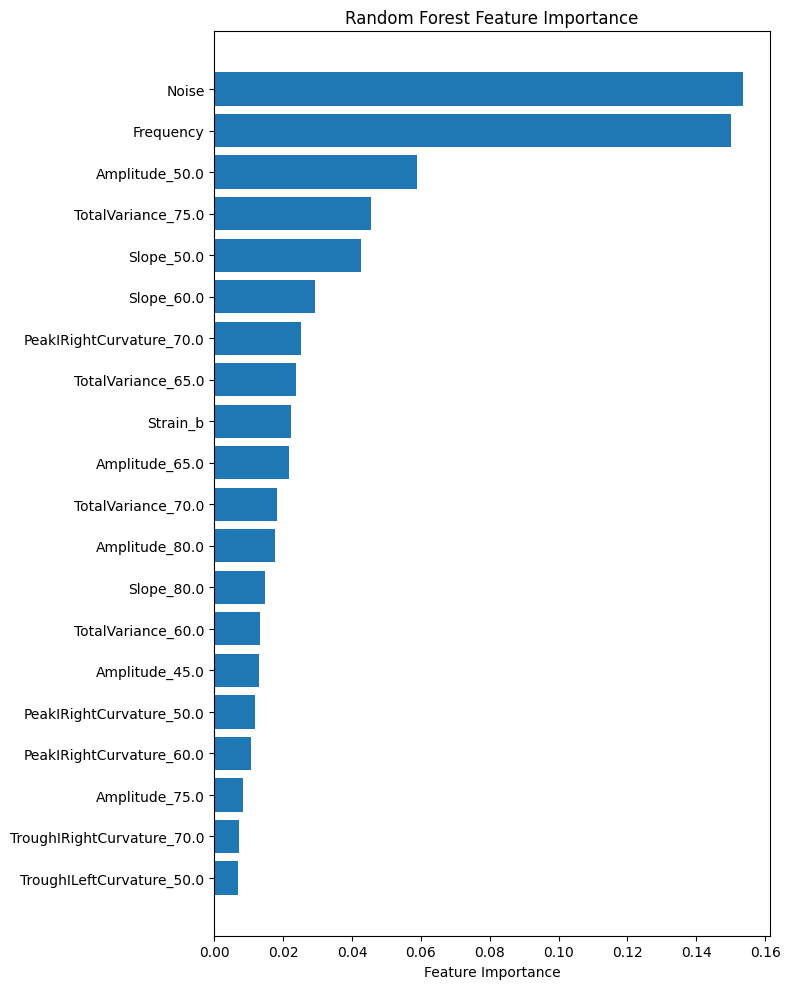

In [13]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(range(20), importance_df["Importance"][:20])
plt.yticks(range(20), importance_df["Feature"][:20])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                          Feature  Importance_Mean  Importance_Std
152                         Noise         0.372082        0.082662
46                      Frequency         0.294364        0.036588
8                  Amplitude_50.0         0.030154        0.004184
25                     Slope_60.0         0.019675        0.004175
11                 Amplitude_65.0         0.015028        0.003552
..                            ...              ...             ...
61             TotalVariance_80.0        -0.002509        0.001075
74        PeakILeftCurvature_70.0        -0.002819        0.000848
127  TroughIOverallCurvature_35.0        -0.003325        0.003631
134  TroughIOverallCurvature_70.0        -0.004383        0.001294
113     TroughILeftCurvature_40.0        -0.004530        0.001179

[154 rows x 3 columns]


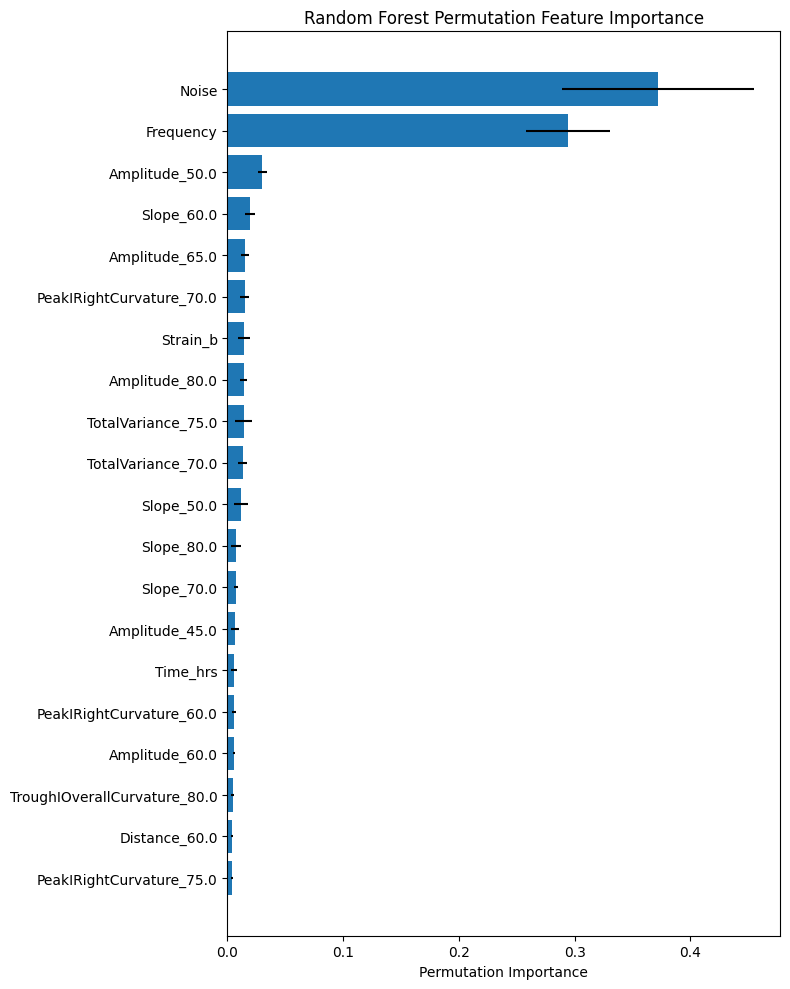

In [14]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 10))
plt.barh(
    range(20),
    perm_importance_df["Importance_Mean"][:20],
    xerr=perm_importance_df["Importance_Std"][:20],
)
plt.yticks(range(20), perm_importance_df["Feature"][:20])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: 0.094, RMSE: 0.965
11.3Hz, 103 samples, R2: 0.150, RMSE: 1.039
16.0Hz, 103 samples, R2: -0.010, RMSE: 1.273
22.6Hz, 103 samples, R2: 0.815, RMSE: 1.770
32.0Hz, 105 samples, R2: 0.543, RMSE: 3.062
45.2Hz, 100 samples, R2: 0.753, RMSE: 2.281
All data, 616 samples, R2: 0.647, RMSE: 2.090


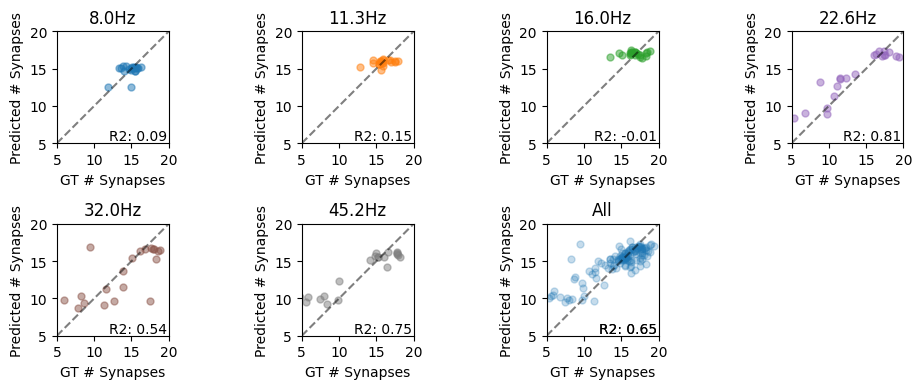

In [16]:
train_plot_result_frequency(reformatted, best_rf_model)